In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:

spy_df = pd.read_csv("D:\\DEV\\assets\\SPY_close_price_5Y.csv", parse_dates=["Date"])

spy_df.head()

,Date,Close
0,2020-11-02,330.20
1,2020-11-03,336.03
2,2020-11-04,343.54
3,2020-11-05,350.24
4,2020-11-06,350.16


In [30]:
spy_df = spy_df.assign(
    ma_50 = spy_df.Close.rolling(window=50, min_periods=50).mean(),
    ma_200 = spy_df.Close.rolling(window=200, min_periods=200).mean(),
    gc = (
        (spy_df.Close.rolling(50).mean() > spy_df.Close.rolling(200).mean()) &
        (spy_df.Close.rolling(50).mean().shift(1) <= spy_df.Close.rolling(200).mean().shift(1))
    ).astype(int)
)


In [31]:
spy_df.columns

Index(['Date', 'Close', 'ma_50', 'ma_200', 'gc'], dtype='object')

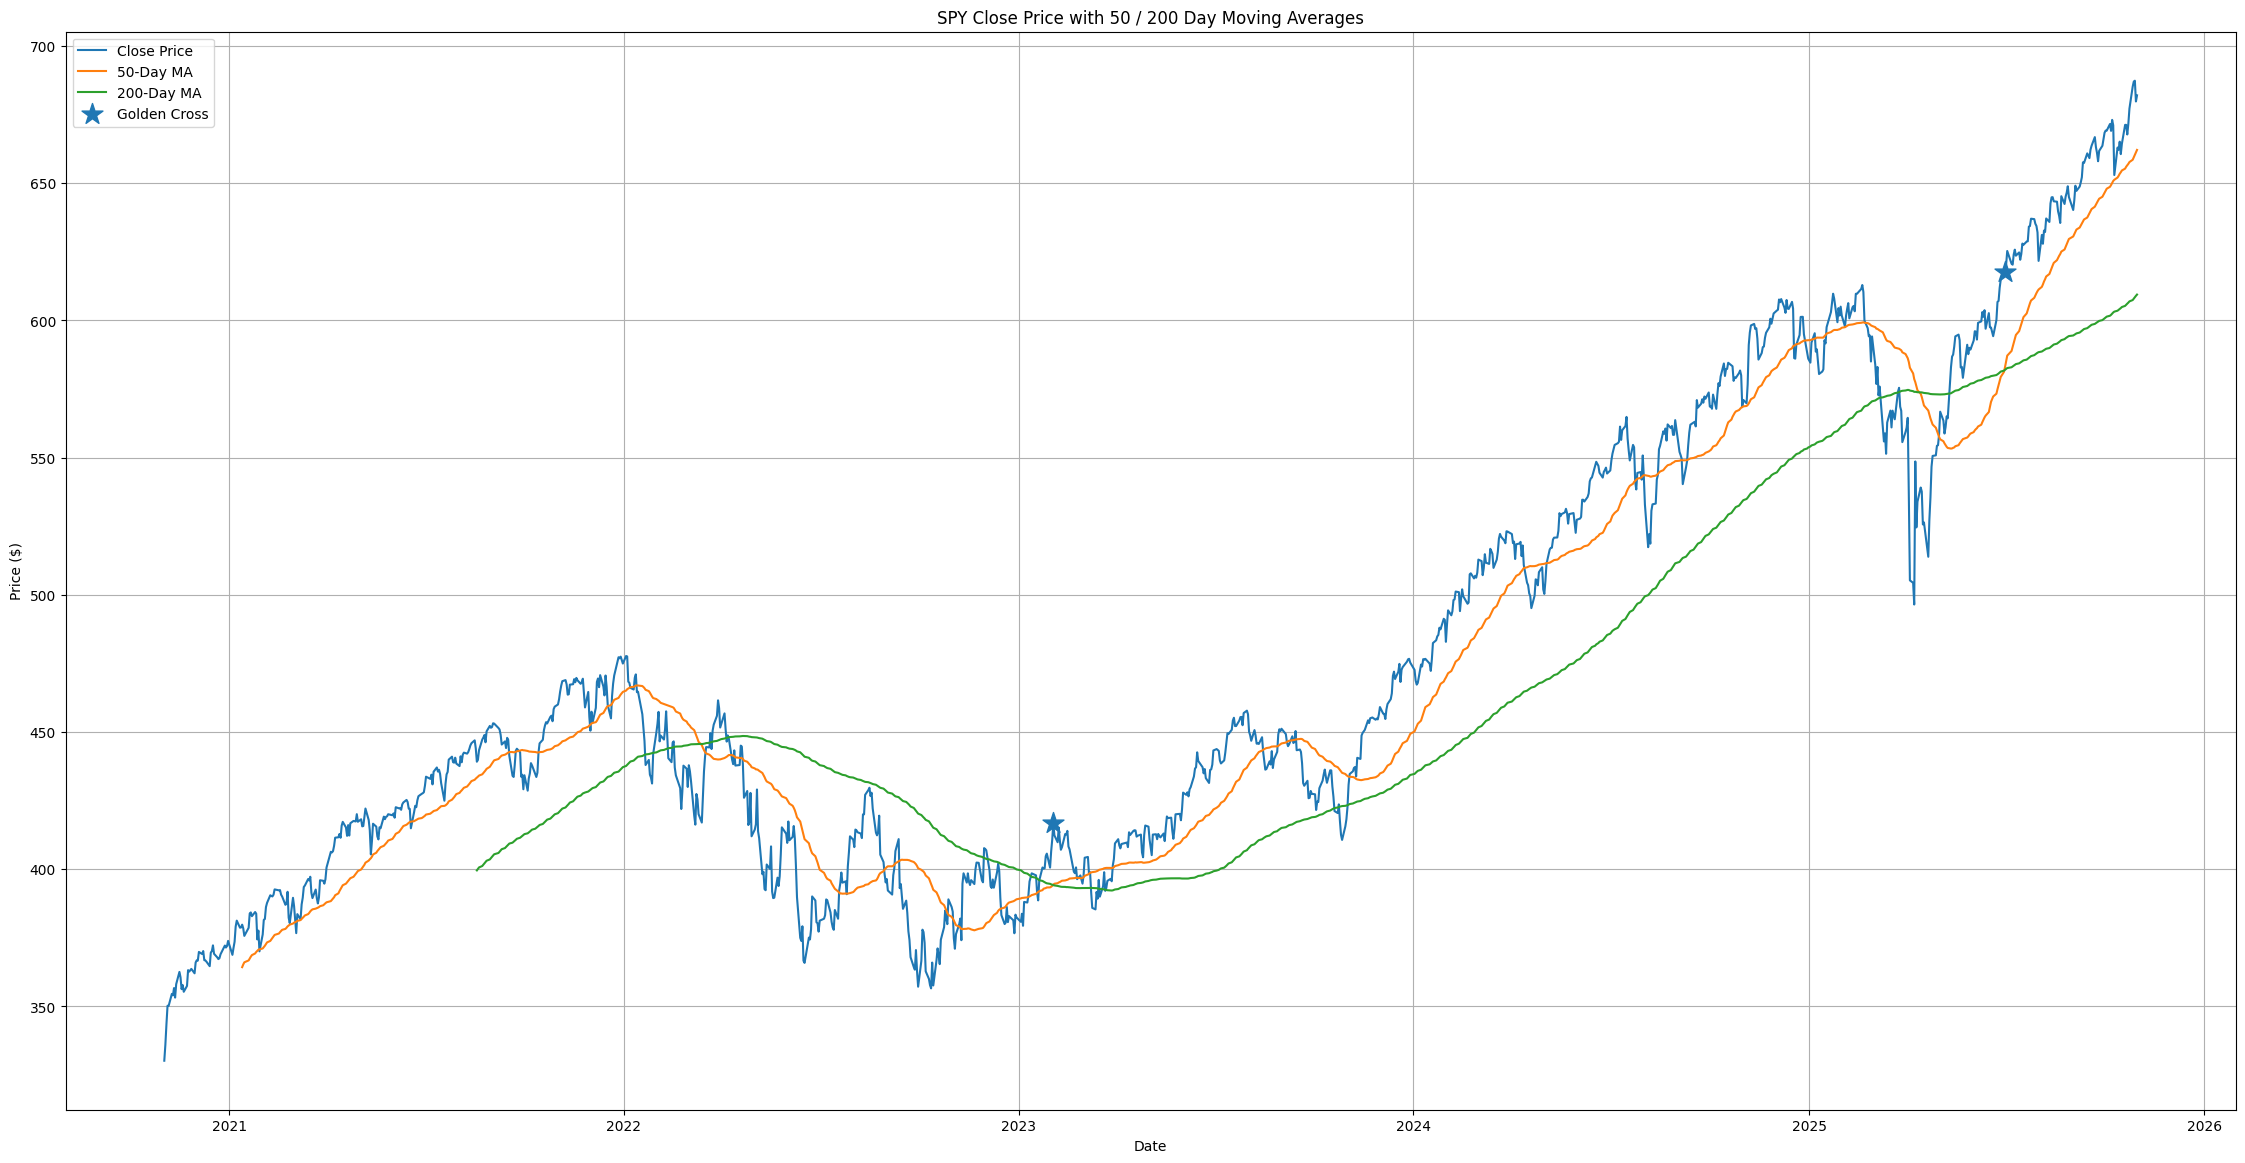

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(28, 14))

# Price & moving averages
plt.plot(spy_df["Date"], spy_df["Close"], label="Close Price")
plt.plot(spy_df["Date"], spy_df["ma_50"], label="50-Day MA")
plt.plot(spy_df["Date"], spy_df["ma_200"], label="200-Day MA")

# Golden Cross markers
gc_points = spy_df[spy_df["gc"] == 1]
plt.scatter(
    gc_points["Date"],
    gc_points["Close"],
    marker="*",
    s=250,
    label="Golden Cross"
)

plt.title("SPY Close Price with 50 / 200 Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)

plt.show()
